In [1]:
import numpyro.distributions as dist
import pandas as pd
import seaborn as sns
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
from numpyro.contrib.funsor import config_enumerate, infer_discrete
from tensorflow_probability.substrates.jax import distributions as tfd
from perturbo import perturbseq_model, perturbseq_guide_autonormal

import jax.numpy as jnp
from jax import random

from numpyro.infer import (
    SVI,
    Trace_ELBO,
    TraceEnum_ELBO,
    TraceGraph_ELBO,
    TraceMeanField_ELBO,
    Predictive,
)
from numpyro.infer.autoguide import AutoNormal, init_to_median
from numpyro import handlers

numpyro.set_platform("cpu")

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


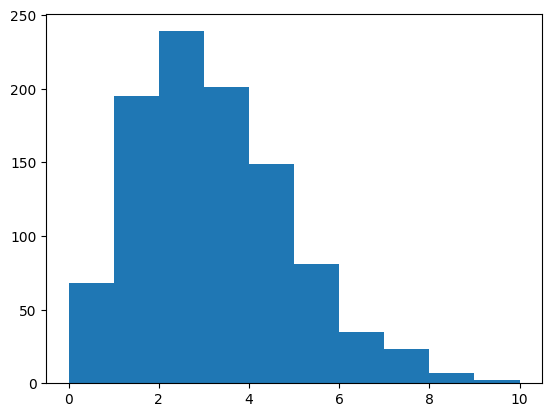

Array(2.723, dtype=float32)

In [2]:
from jax.random import PRNGKey
from tensorflow_probability.substrates.jax.distributions import quadrature_scheme_lognormal_gauss_hermite

samples = tfd.PoissonLogNormalQuadratureCompound(
    jnp.array(1.0), jnp.array(0.1), quadrature_fn=quadrature_scheme_lognormal_gauss_hermite
).sample(
    sample_shape=(1000,),
    seed=PRNGKey(2),
)

plt.hist(samples)
plt.show()

samples.mean()

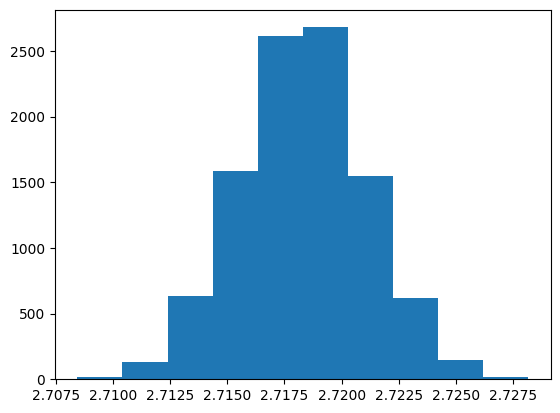

In [3]:
samples = dist.LogNormal(1.0, 0.001).sample(key=PRNGKey(0), sample_shape=(10000,))
plt.hist(samples)
plt.show()

In [4]:
# %pip install --upgrade pip funsor numpyro

In [5]:
# cell count params
n_control = 1000
n_perturbed = 200
n_cells = n_control + n_perturbed

# gene params
n_genes = 1
gene_mean = jnp.array([2.0])
gene_disp = jnp.array([2.0])
# n_genes = 2
# gene_mean = jnp.array([10.0, 5.0])
# gene_disp = jnp.array([50.0, 10.0])

# guide params
n_guides = 2
efficiency = jnp.ones((n_guides, 1))
# efficiency = jnp.linspace(0.1, 0.9, num=n_guides).reshape(-1, 1)
log2_fc = jnp.array([-1.0])

guides_control = jnp.zeros((n_control, n_guides))
guides_perturbed = jnp.eye(n_guides).repeat(n_perturbed // n_guides, axis=0)
guide_obs = jnp.vstack((guides_control, guides_perturbed))

print(guide_obs.shape)
print(efficiency.shape)

(1200, 2)
(2, 1)


In [6]:
# perturbseq_model

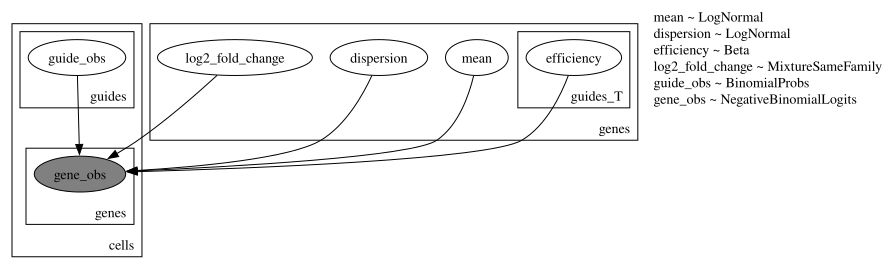

In [7]:
numpyro.render_model(
    perturbseq_model,
    model_args=(jnp.zeros((1,1)),),
    render_distributions=True,
    render_params=True,
)

In [8]:
rng_key = random.PRNGKey(0)

# Define your model parameters

# Create a predictive model
predictive = Predictive(perturbseq_model, num_samples=1)

# Sample from the model prior
prior_samples = predictive(
    rng_key,
    None,
    n_cells=n_cells,
    n_guides=n_guides,
    n_genes=n_genes,
)

In [9]:
prior_samples["gene_obs"]

Array([[[0],
        [0],
        [0],
        ...,
        [0],
        [0],
        [0]]], dtype=int32)

dispersion (1,)
[2.2857606]
efficiency (1, 2)
[[0.61633843 0.70573837]]
gene_obs (1, 1200)


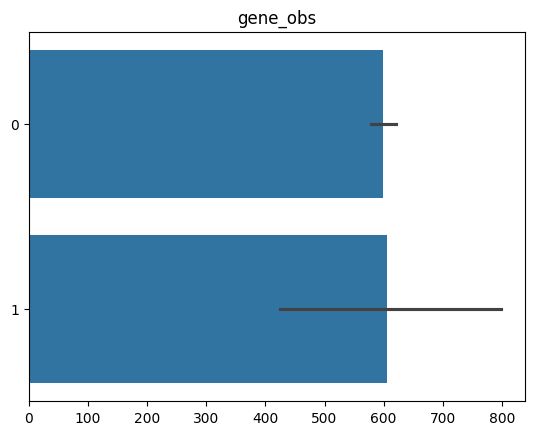

guide_obs (1, 1200)


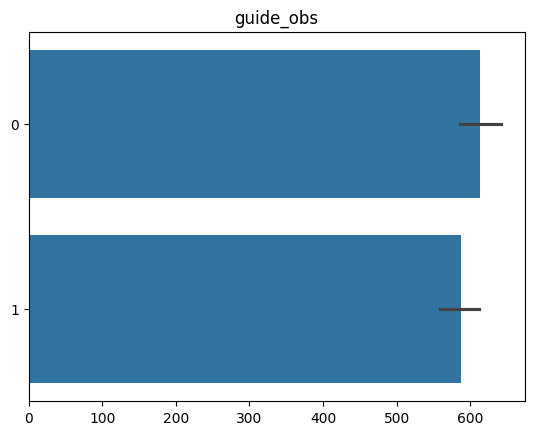

log2_fold_change (1,)
[-0.01356162]
mean (1,)
[0.0066966]


In [10]:
for k, v in prior_samples.items():
    # if k in model_params:
    #     continue
    v = v[..., 0]
    print(k, v.shape)
    # if n_cells not in v.shape:
    if "_obs" in k:
        v = v.reshape(-1)
        plt.title(k)
        v_max = v.max()
        if v_max == 1:
            sns.barplot([str(int(x)) for x in v])
        else:
            sns.histplot(v.astype(int), bins=range(int(v.max()) + 1))
        plt.show()
        pass
        # v = v.squeeze()
        # print(k, v.shape)
        # sns.barplot(v)
    elif sum(v.shape) <= 5:
        print(v)
    else:
        sns.histplot(v)
        plt.show()

# break

In [11]:
model_params = {
    "guide_obs": guide_obs,
    "log2_fc": log2_fc,
    "efficiency": efficiency,
    "gene_mean": gene_mean,
    "gene_disp": gene_disp,
}
prior_conditional_samples = predictive(rng_key, None, **model_params)

gene_obs = prior_conditional_samples["gene_obs"][0, ...]
gene_obs.shape

(1200, 1)

In [12]:
data_df = pd.DataFrame(gene_obs).assign(guide=guide_obs.argmax(axis=1) + (guide_obs.sum(axis=1) > 0))
data_df
data_df.value_counts("guide")

guide
0    1000
1     100
2     100
Name: count, dtype: int64

In [13]:
gene_obs.shape

(1200, 1)

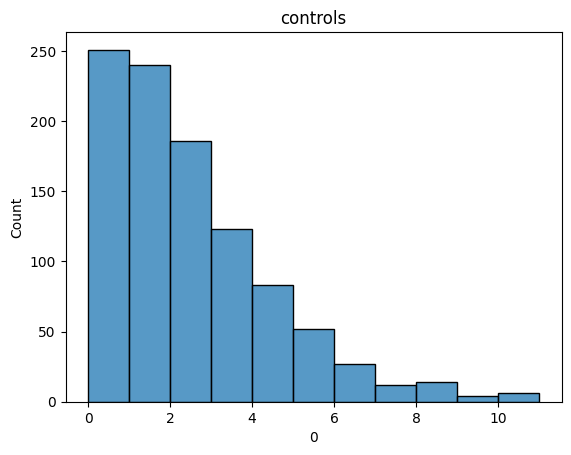

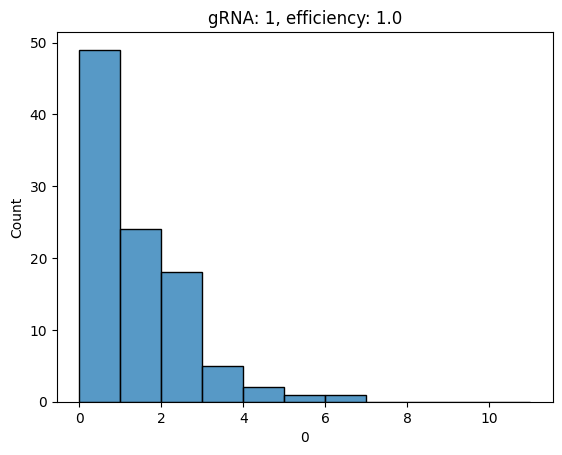

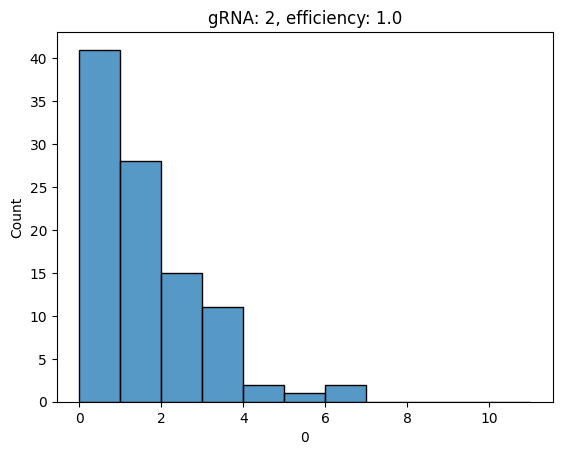

In [14]:
max_count = data_df.values.max()
counts_col = 0
bins = np.arange(max_count).astype(int)
plt.title("controls")
sns.histplot(data_df.query("guide==0"), x=counts_col, bins=bins)
plt.show()
for guide in range(n_guides):
    plt.title(f"gRNA: {guide+1}, efficiency: {efficiency[guide,0]:.1f}")
    sns.histplot(data_df.query(f"guide=={guide+1}"), x=counts_col, bins=bins)
    plt.show()

In [15]:
def train(args, kwargs, model, guide, lr=0.01, n_steps=1000):
    # adam_params = {"lr": lr}
    adam = numpyro.optim.Adam(step_size=lr)
    svi = SVI(
        model,
        guide,
        adam,
        loss=TraceGraph_ELBO(),
    )
    svi_result = svi.run(random.PRNGKey(0), n_steps, args, **kwargs)
    return svi_result

In [16]:
perturbseq_guide = perturbseq_guide_autonormal()

100%|██████████| 4000/4000 [00:02<00:00, 1683.85it/s, init loss: 5650.4531, avg. loss [3801-4000]: 3864.0975]


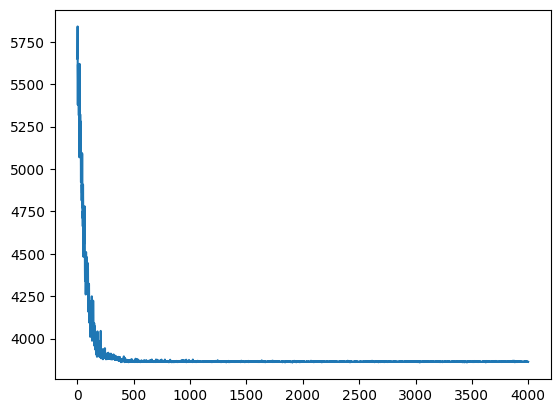

In [17]:
svi_result = train(
    gene_obs,
    {"guide_obs": guide_obs, "subsample_size": None},
    perturbseq_model,
    perturbseq_guide,
    n_steps=4000,
    lr=0.01,
)
# losses = train(gene_obs, dict(guide_obs=guide_obs, log2_fc=log2_fc, latent_activity=True), perturbseq_model, perturbseq_guide_autonormal)
plt.plot(svi_result.losses)

In [18]:
unconstrained_locs = dict()
for k, v in svi_result.params.items():
    print(k, v.shape, v)
    param, param_type = k.split("_auto_")
    if param_type == "loc":
        unconstrained_locs[param] = v
print(unconstrained_locs)

dispersion_auto_loc (1,) [0.621828]
dispersion_auto_scale (1,) [0.09823537]
efficiency_auto_loc (2, 1) [[2.1535337]
 [1.0503851]]
efficiency_auto_scale (2, 1) [[0.9233867]
 [0.6406572]]
log2_fold_change_auto_loc (1,) [-1.1717427]
log2_fold_change_auto_scale (1,) [0.15643226]
mean_auto_loc (1,) [0.7203852]
mean_auto_scale (1,) [0.0303231]
{'dispersion': Array([0.621828], dtype=float32), 'efficiency': Array([[2.1535337],
       [1.0503851]], dtype=float32), 'log2_fold_change': Array([-1.1717427], dtype=float32), 'mean': Array([0.7203852], dtype=float32)}


In [19]:
# perturbseq_guide_autonormal_autonormal_autonormal_autonormal_autonormal.median()
# svi.get_p
predictive_svi = Predictive(
    perturbseq_guide,
    params=svi_result.params,
    num_samples=10000,
)

svi_posterior_samples = predictive_svi(rng_key, None, guide_obs=guide_obs, n_genes=n_genes)

svi_posterior_samples.keys()

dict_keys(['dispersion', 'efficiency', 'log2_fold_change', 'mean'])

In [20]:
# locs = {k: perturbseq_guide._get_loc_and_scale(k)[0].detach() for k in perturbseq_guide..()}
# locs
params = svi_result.params
params

{'dispersion_auto_loc': Array([0.621828], dtype=float32),
 'dispersion_auto_scale': Array([0.09823537], dtype=float32),
 'efficiency_auto_loc': Array([[2.1535337],
        [1.0503851]], dtype=float32),
 'efficiency_auto_scale': Array([[0.9233867],
        [0.6406572]], dtype=float32),
 'log2_fold_change_auto_loc': Array([-1.1717427], dtype=float32),
 'log2_fold_change_auto_scale': Array([0.15643226], dtype=float32),
 'mean_auto_loc': Array([0.7203852], dtype=float32),
 'mean_auto_scale': Array([0.0303231], dtype=float32)}

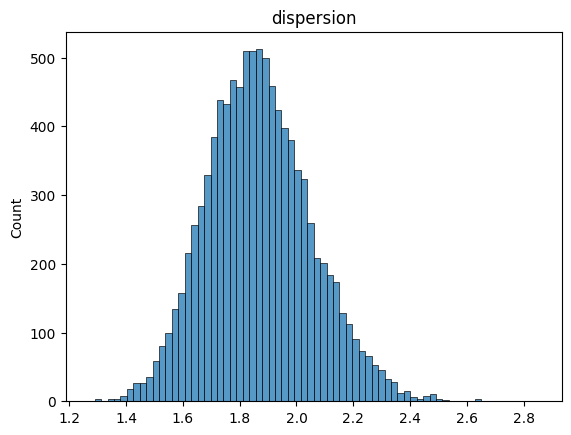

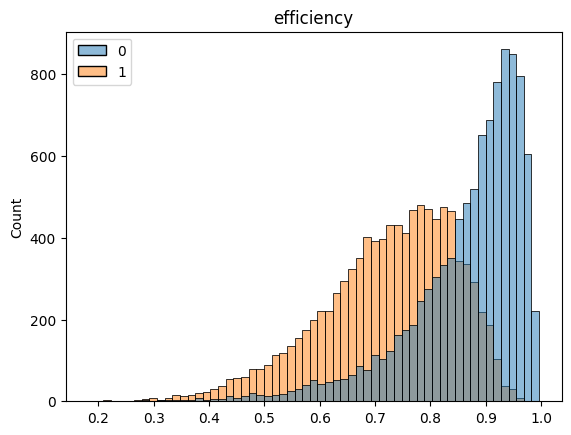

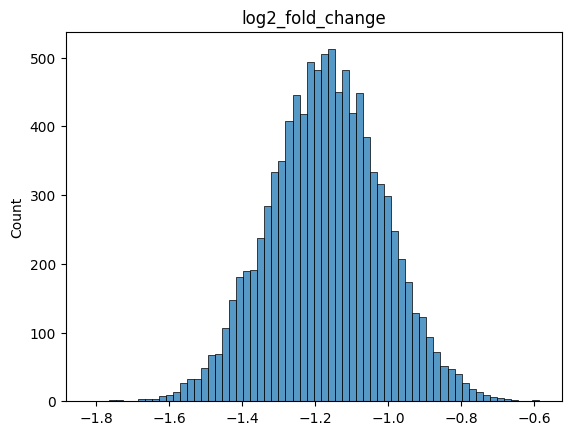

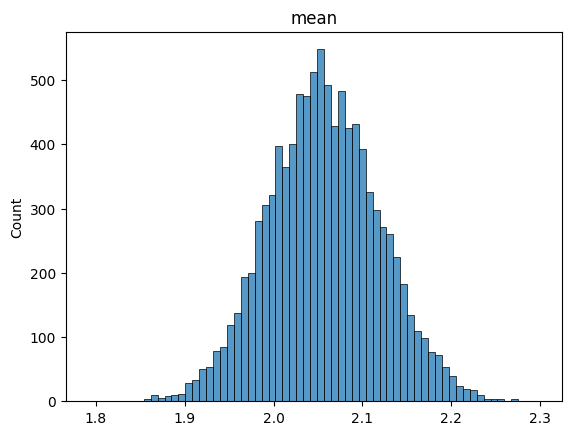

In [21]:
for k, v in svi_posterior_samples.items():
    v = v[..., 0]
    plt.title(k)
    sns.histplot(v)
    plt.show()

In [22]:
# break

## MCMC


In [23]:
from numpyro.infer import MCMC, NUTS, HMCECS, DiscreteHMCGibbs

n_chains = 1

kernel = NUTS(
    perturbseq_model,
    dense_mass=True
    # dense_mass=[("mean", "dispersion", "log2_fold_change")],
)
# kernel = DiscreteHMCGibbs(kernel, random_walk=True)


mcmc = MCMC(kernel, num_samples=10000, num_warmup=1000, num_chains=n_chains)

In [24]:
mcmc.run(random.PRNGKey(0), gene_obs, **{"guide_obs": guide_obs}, init_params=unconstrained_locs)

sample: 100%|██████████| 11000/11000 [00:14<00:00, 784.56it/s, 7 steps of size 3.18e-01. acc. prob=0.94] 


In [25]:
samples = mcmc.get_samples()
samples

{'dispersion': Array([[1.99543  ],
        [1.6343905],
        [1.631224 ],
        ...,
        [1.8499515],
        [1.907866 ],
        [1.8176726]], dtype=float32),
 'efficiency': Array([[[0.9023264 ],
         [0.7463653 ]],
 
        [[0.95023143],
         [0.9662366 ]],
 
        [[0.84440637],
         [0.7675054 ]],
 
        ...,
 
        [[0.8972269 ],
         [0.63881254]],
 
        [[0.95236933],
         [0.8409745 ]],
 
        [[0.93331695],
         [0.5166527 ]]], dtype=float32),
 'log2_fold_change': Array([[-1.46778  ],
        [-0.9632581],
        [-1.2940829],
        ...,
        [-1.30575  ],
        [-1.1569673],
        [-1.1236663]], dtype=float32),
 'mean': Array([[2.171583 ],
        [2.024396 ],
        [2.041387 ],
        ...,
        [2.2225132],
        [2.1046646],
        [2.1545339]], dtype=float32)}

In [26]:
for k, v in samples.items():
    v = v[..., 0]
    samples[k] = v
    print(f"{k}: {tuple(v.shape)}")

dispersion: (10000,)
efficiency: (10000, 2)
log2_fold_change: (10000,)
mean: (10000,)


In [27]:
samples["mean"]

Array([2.171583 , 2.024396 , 2.041387 , ..., 2.2225132, 2.1046646,
       2.1545339], dtype=float32)

(array([3.000e+00, 7.300e+01, 6.330e+02, 2.199e+03, 3.303e+03, 2.590e+03,
        9.690e+02, 2.020e+02, 2.600e+01, 2.000e+00]),
 array([1.78178084, 1.83936501, 1.89694917, 1.95453334, 2.01211762,
        2.06970167, 2.12728596, 2.18487   , 2.24245429, 2.30003834,
        2.35762262]),
 <BarContainer object of 10 artists>)

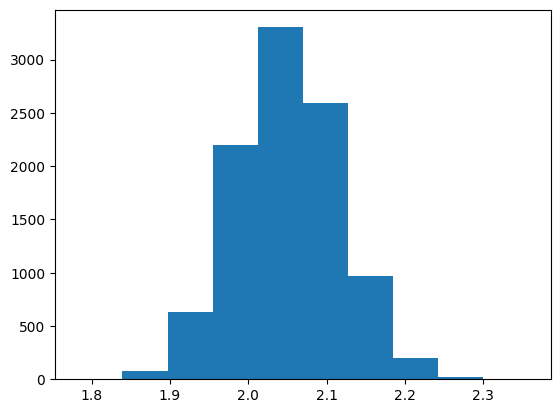

In [28]:
plt.hist(samples["mean"])

Array([1.99543  , 1.6343905, 1.631224 , ..., 1.8499515, 1.907866 ,
       1.8176726], dtype=float32)

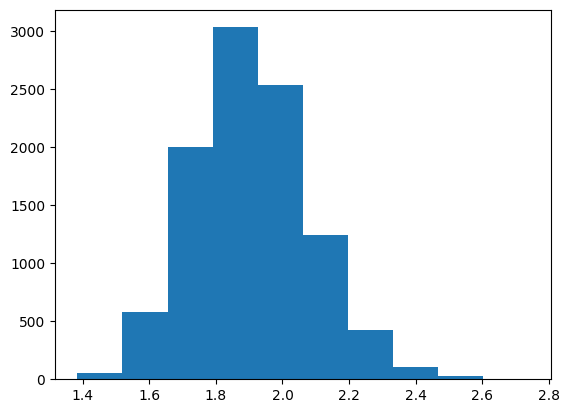

In [29]:
plt.hist(samples["dispersion"])
samples["dispersion"]

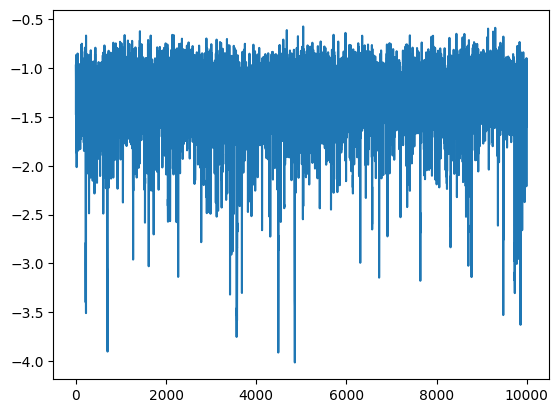

In [30]:
plt.plot(samples["log2_fold_change"])

<Axes: ylabel='Count'>

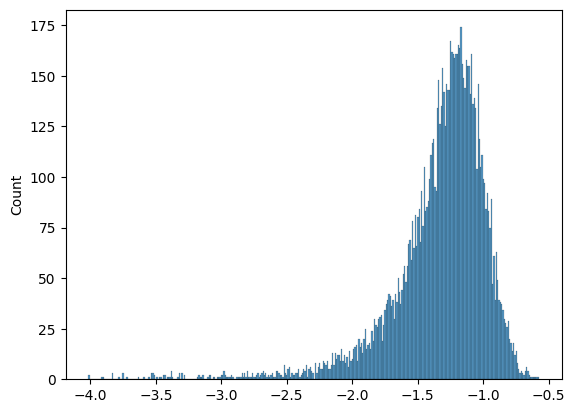

In [31]:
sns.histplot(samples["log2_fold_change"], binwidth=0.01)

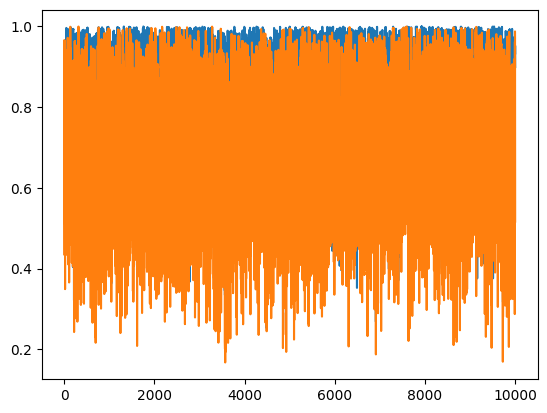

In [32]:
plt.plot(samples["efficiency"])

<Axes: ylabel='Count'>

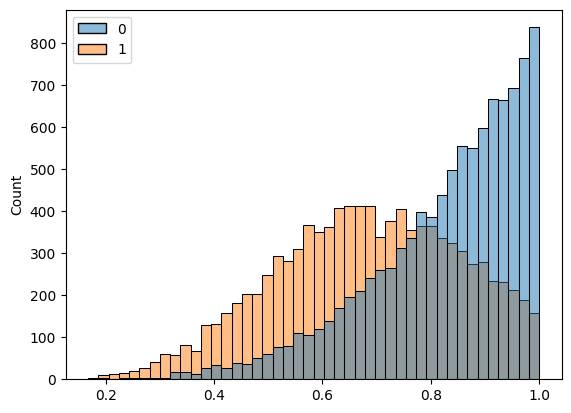

In [33]:
sns.histplot(samples["efficiency"])

<Axes: ylabel='Count'>

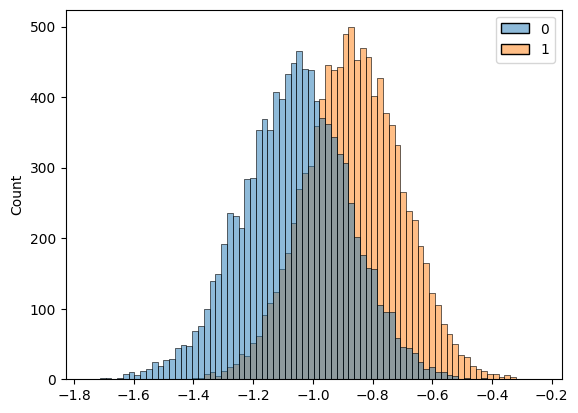

In [34]:
sns.histplot(samples["efficiency"] * samples["log2_fold_change"].reshape(-1, 1))

<Axes: ylabel='Count'>

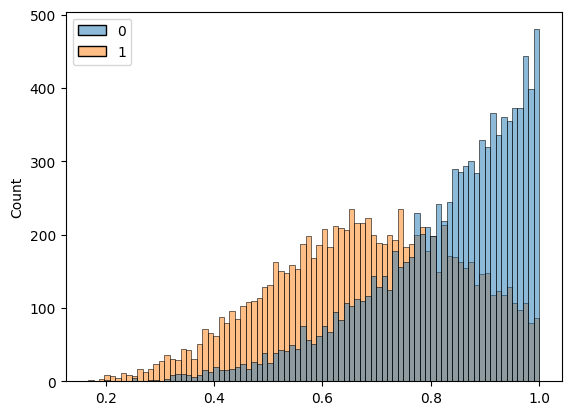

In [35]:
sns.histplot(pd.DataFrame(samples["efficiency"]), binwidth=0.01)